In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.rdMolDescriptors import CalcMolFormula
from rdkit import RDLogger
IPythonConsole.molSize = (450, 450)
import pickle as pkl
import numpy as np
import pandas as pd
from sys import path
path.append('../src')
from src.metrics.diffms_metrics import K_ACC_Collection
import warnings
RDLogger.DisableLog('rdApp.*')

In [5]:
pred_arrs = []
true_arrs = []
for i in range(0, 3):
    with open(f'data/outputs_epoch50/dev_resume_pred_{i}.pkl', 'rb') as f:
        pred_arr = pkl.load(f)
    with open(f'data/outputs_epoch50/dev_resume_true_{i}.pkl', 'rb') as f:
        true_arr = pkl.load(f)
    pred_arrs.append(pred_arr)
    true_arrs.append(true_arr)
    
pred_mols = np.array(pred_arrs).reshape((3072, 10))
true_mols = np.array(true_arrs).flatten()
print(f'true_mols.shape: {true_mols.shape}')
print(f'pred_mols.shape: {pred_mols.shape}')

true_mols.shape: (3072,)
pred_mols.shape: (3072, 10)


In [326]:
if False:
    def fix_malformed_nitro(mol: Chem.Mol) -> Chem.Mol:
        mol = Chem.RWMol(mol)
        to_fix = []

        for atom in mol.GetAtoms():
            if atom.GetAtomicNum() != 7:  # Not nitrogen
                continue
            #if atom.GetDegree() != 3:
            #    continue

            o_double = None
            o_single = None

            for neighbor in atom.GetNeighbors():
                if neighbor.GetAtomicNum() != 8:
                    continue
                bond = mol.GetBondBetweenAtoms(atom.GetIdx(), neighbor.GetIdx())
                if bond.GetBondType() == Chem.rdchem.BondType.DOUBLE:
                    o_double = neighbor
                elif bond.GetBondType() == Chem.rdchem.BondType.SINGLE:
                    if len([nbr for nbr in neighbor.GetNeighbors() if nbr.GetIdx() != atom.GetIdx()]) == 0:
                        o_single = neighbor

            if o_double != None and o_single != None:
                to_fix.append((atom.GetIdx(), o_single.GetIdx()))

        # Apply fixes
        for n_idx, o_idx in to_fix:
            mol.GetAtomWithIdx(n_idx).SetFormalCharge(+1)
            mol.GetAtomWithIdx(o_idx).SetFormalCharge(-1)

        return mol.GetMol()

In [327]:
if False:
    with open(f'generated_mols.pkl', 'rb') as f:
        pred_mols = np.array(pkl.load(f))
        generated_mols_no_hs = []
        generated_mols_no_hs_nitro_fix = []
        for mol_list in pred_mols:
            mol_list_no_h = []
            mol_list_no_h_nitro_fix = []
            for mol in mol_list:
                try:
                    mol_no_h = Chem.RemoveHs(mol, sanitize=False)
                    mol_list_no_h.append(mol_no_h)
                    mol_list_no_h_nitro_fix.append(fix_malformed_nitro(mol_no_h))
                except Chem.AtomValenceException: 
                    print('Explicit valence is greater than permitted')
            generated_mols_no_hs.append(mol_list_no_h)
            generated_mols_no_hs_nitro_fix.append(mol_list_no_h_nitro_fix)
        pred_mols = np.array(generated_mols_no_hs_nitro_fix)
    df_labels = pd.read_csv('../data/neims/labels.tsv', sep='\t')
    true_mol_uid = np.loadtxt('batch_names.txt', dtype=np.str_)
    print(f'true_mol_uid.shape: {true_mol_uid.shape}')
    df_labels = df_labels[df_labels['spec'].isin(true_mol_uid)]
    true_mols = df_labels['smiles'].apply(lambda smi: Chem.RemoveAllHs(Chem.MolFromSmiles(smi))).values
    print(f'true_mols.shape: {true_mols.shape}')
    print(f'pred_mols.shape: {pred_mols.shape}')
    true_mols[998]

In [6]:
matches_idx = []
no_matches_idx = []
for idx, true_mol in enumerate(true_mols):
    found_match = False
    true_inchi = Chem.MolToInchi(true_mol)
    for pred_mol in pred_mols[idx]:
        try:
            pred_inchi = Chem.MolToInchi(pred_mol)
            if pred_inchi == true_inchi:
                found_match = True
        except:
            print('Invalid molecule')
    if found_match:
        matches_idx.append(idx)
    else:
        no_matches_idx.append(idx)

Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecu

In [7]:
matches_idx = np.array(matches_idx)
no_matches_idx = np.array(no_matches_idx)

In [8]:
matches_idx.shape

(405,)

In [9]:
no_matches_idx.shape

(2667,)

In [10]:
mol_idx = 510

In [11]:
preds = iter(pred_arr[mol_idx])
true_mol = true_arr[mol_idx]

515


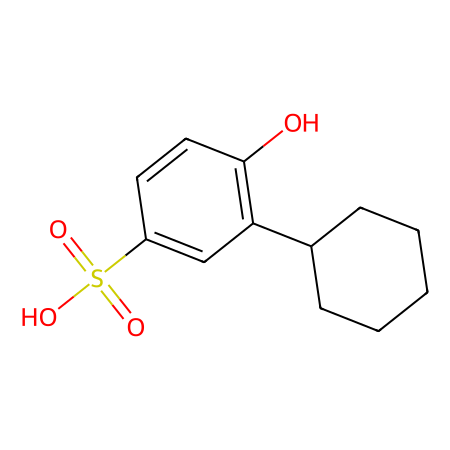

In [24]:
# difficult cases 52, 67, 79, 91, 144, 286
# 104
mol_idx +=1 
print(mol_idx)
true_mol = true_arr[mol_idx]
mol = true_mol
mol

In [25]:
preds = iter(pred_arr[mol_idx])

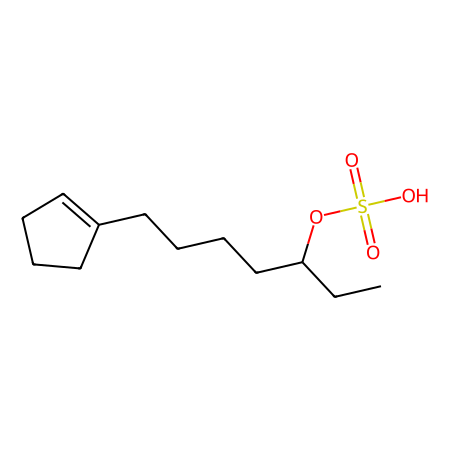

In [32]:
next(preds)

In [338]:
import matplotlib.pyplot as plt

def make_fig(df, name: str, annotate=True, min_intensity=0.1):
    spec = df[df['name'] == name]['spec'].values[0].T
    mz = spec[0, :]
    inten = spec[1, :]
    inten_scaled = inten / inten.max()

    #mask = inten_scaled > min_intensity
    #inten_scaled = inten_scaled[mask]
    #mz = mz[mask]

    plt.figure(figsize=(8, 3.8), dpi=350)
    plt.vlines(mz, 0, inten_scaled, color='#e1aee4', linewidth=1.5)

    # 🔹 Add labels on top of peaks
    if annotate:
        for x, y in zip(mz, inten_scaled):
            if y >= min_intensity:  # avoid clutter from tiny peaks
                plt.text(
                    x, y + 0.02,           # slight vertical offset
                    f"{int(round(x))}",    # label = m/z value
                    ha='center',
                    va='bottom',
                    fontsize=7
                )

    plt.xlabel('m/z')
    plt.ylabel('Relative intensity')
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.ylim([0, 1.05])
    plt.title('EI-MS spectrum (Model input)', fontsize=12)
    plt.tight_layout()
    plt.show()
def mol_from_smiles_df(df, name):
    return Chem.MolFromSmiles(df[df['name'] == name]['SMILES'].values[0])

In [339]:
df = pd.read_pickle('../data/atmomaccs/spec_files/df_neims_atmomaccs_3_9_22.pkl')
df[df['name'] == 'ferraz-caetano_716']

,SMILES,spec,name
716,C12(C(C(C(C(C1(F)F)(F)F)(F)F)(F)F)(C(C(C(C2(F)...,"[[31, 166], [43, 230], [44, 102], [47, 0], [50...",ferraz-caetano_716


In [16]:
make_fig(df, 'ferraz-caetano_716')

NameError: name 'make_fig' is not defined

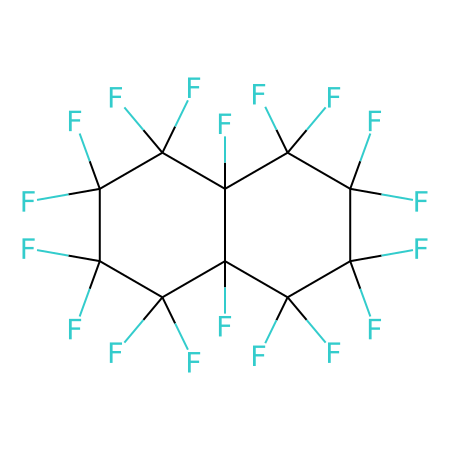

In [341]:
mol_from_smiles_df(df, 'ferraz-caetano_716')

In [342]:
raise Exception

Exception: 

In [15]:
metric = K_ACC_Collection(k_list=[1, 5, 10])
metric.reset()

for pred_arr, true_arr in zip(pred_arrs, true_arrs):   # loop over the 5 files
    for preds, true_smiles in zip(pred_arr, true_arr): # loop inside each file
        metric.update(preds, true_smiles)

results = metric.compute()
results

{'acc_at_1': 0.039388020833333336,
 'acc_at_5': 0.09798177083333333,
 'acc_at_10': 0.1318359375}

In [ ]:
pred_arrs = []
true_arrs = []
for i in range(0, 5):
    with open(f'data/outputs/dev_pred_{i}.pkl', 'rb') as f:
        pred_arr = pkl.load(f)
    with open(f'data/outputs/dev_true_{i}.pkl', 'rb') as f:
        true_arr = pkl.load(f)
    pred_arrs.append(pred_arr)
    true_arrs.append(true_arr)

In [ ]:
metric = K_ACC_Collection(k_list=[1, 5, 10])
metric.reset()

for pred_arr, true_arr in zip(pred_arrs, true_arrs):   # loop over the 5 files
    for preds, true_smiles in zip(pred_arr, true_arr): # loop inside each file
        metric.update(preds, true_smiles)

results = metric.compute()
results

{'acc_at_1': 0.6689453125, 'acc_at_5': 0.91875, 'acc_at_10': 0.9453125}